## Load the Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

## Load the Data

In [15]:
sales_df = pd.read_csv('sales_data.csv')
product_df = pd.read_csv('product_info.csv')
customer_df = pd.read_csv('customer_info.csv')

In [16]:

print("Shapes:", sales_df.shape, product_df.shape, customer_df.shape)

Shapes: (3000, 10) (30, 6) (500, 6)


## Cleaning the Data

In [17]:
# Clean product_info.csv
print("Product Info before cleaning - Shape:", product_df.shape)
product_df['category'] = product_df['category'].str.strip().str.title()
product_df['supplier_code'] = product_df['supplier_code'].str.strip().str.upper()
product_df['launch_date'] = pd.to_datetime(product_df['launch_date'], format='%d-%m-%y', errors='coerce')


# No missing values, no duplicates (30 unique product_id), base_price all positive
print("Product Info after cleaning - Shape:", product_df.shape)
print("Product Info missing values:\n", product_df.isnull().sum())

Product Info before cleaning - Shape: (30, 6)
Product Info after cleaning - Shape: (30, 6)
Product Info missing values:
 product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64


In [18]:
# Clean customer_info.csv
print("\nCustomer Info before cleaning - Shape:", customer_df.shape)
customer_df['customer_id'] =customer_df['customer_id'].str.strip()
customer_df['email'] = customer_df['email'].str.strip()
customer_df['gender'] = customer_df['gender'].str.strip().str.title().replace({'Femle': 'Female'})
customer_df['region'] =customer_df['region'].str.strip().str.title()
customer_df['loyalty_tier'] = customer_df['loyalty_tier'].str.strip().str.title().replace({'Gld': 'Gold', 'Brnze': 'Bronze', 'Sllver': 'Silver'})
customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'], format='%d-%m-%y', errors='coerce')


# Handle missing: drop rows with missing customer_id (3 rows), fill others with 'Unknown'
df_customer = customer_df.dropna(subset=['customer_id'])
df_customer['gender'] = df_customer['gender'].fillna('Unknown')
df_customer['region'] = df_customer['region'].fillna('Unknown')
df_customer['loyalty_tier'] = df_customer['loyalty_tier'].fillna('Unknown')
df_customer = df_customer.drop_duplicates(subset=['customer_id'])
print("Customer Info after cleaning - Shape:", df_customer.shape)
print("Customer Info missing values:\n", df_customer.isnull().sum())


Customer Info before cleaning - Shape: (500, 6)
Customer Info after cleaning - Shape: (497, 6)
Customer Info missing values:
 customer_id     0
email           6
signup_date     4
gender          0
region          0
loyalty_tier    0
dtype: int64


In [19]:
# Clean sales_data.csv
print("\nSales before cleaning - Shape:", sales_df.shape)
sales_df['delivery_status'] = sales_df['delivery_status'].str.strip().str.title()
sales_df['payment_method'] = sales_df['payment_method'].str.strip().str.title()
sales_df['region'] = sales_df['region'].str.strip().str.title()
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'], format='%d-%m-%Y', errors='coerce')
sales_df['discount_applied'] = sales_df['discount_applied'].fillna(0.0)
sales_df['customer_id'] = sales_df['customer_id'].str.strip()
sales_df['product_id'] = sales_df['product_id'].str.strip()

# Convert numerics safely (coerce errors to NaN, fill NaN with 1 for quantity)
sales_df['quantity'] = pd.to_numeric(sales_df['quantity'], errors='coerce').fillna(1).astype(int)
# unit_price and discount_applied already float64, but ensure non-neg
sales_df['unit_price'] = pd.to_numeric(sales_df['unit_price'], errors='coerce').fillna(0.0)


# Validate numerics
sales_df = sales_df[sales_df['quantity'] >= 0]
sales_df = sales_df[sales_df['unit_price'] >= 0]
sales_df = sales_df[sales_df['discount_applied'] >= 0]


# Drop rows with missing critical keys
sales_df = sales_df.dropna(subset=['order_id', 'customer_id', 'product_id'])
sales_df = sales_df.drop_duplicates(subset=['order_id'])
print("Sales after cleaning - Shape:", sales_df.shape)
print("Sales missing values:\n", sales_df.isnull().sum())
print("\nInvalid numerics filtered - quantity min:", sales_df['quantity'].min(), "unit_price min:", sales_df['unit_price'].min())


Sales before cleaning - Shape: (3000, 10)
Sales after cleaning - Shape: (2990, 10)
Sales missing values:
 order_id            0
customer_id         0
product_id          0
quantity            0
unit_price          0
order_date          2
delivery_status     3
payment_method      3
region              0
discount_applied    0
dtype: int64

Invalid numerics filtered - quantity min: 1 unit_price min: 0.0


In [20]:
# Save cleaned DataFrames
product_df.to_csv('product_info_cleaned.csv', index=False)
customer_df.to_csv('customer_info_cleaned.csv', index=False)
sales_df.to_csv('sales_data_cleaned.csv', index=False)


print("\nCleaned DataFrames saved. Ready for merging.")


Cleaned DataFrames saved. Ready for merging.


### Merge Data

In [21]:
# Merge 1: sales + product_info on product_id (left=keep all sales)
merged_sales_product = sales_df.merge(product_df, on='product_id', how='left')

# Merge 2: result + customer_info on customer_id (left=keep all transactions)
merged_df = merged_sales_product.merge(customer_df, on='customer_id', how='left')


print("\nMerged_df shape() :", merged_df.shape)
print("\nMerged_df.info():")
merged_df.info()
print("\nMerged_df.head():")
print(merged_df.head())

merged_df.to_csv('merged_df.csv', index=False)
print("\n Merged_df saved (ready for analysis/visuals)!")


Merged_df shape() : (2990, 20)

Merged_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2990 entries, 0 to 2989
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2990 non-null   object        
 1   customer_id       2990 non-null   object        
 2   product_id        2990 non-null   object        
 3   quantity          2990 non-null   int64         
 4   unit_price        2990 non-null   float64       
 5   order_date        2988 non-null   datetime64[ns]
 6   delivery_status   2987 non-null   object        
 7   payment_method    2987 non-null   object        
 8   region_x          2990 non-null   object        
 9   discount_applied  2990 non-null   float64       
 10  product_name      2990 non-null   object        
 11  category          2990 non-null   object        
 12  launch_date       2990 non-null   datetime64[ns]
 13  base_price        2990 non-

## Feature Engineering

In [22]:
# 1. revenue = quantity × unit_price × (1 - discount_applied)
merged_df['revenue'] = merged_df['quantity'] * merged_df['unit_price'] * (1 - merged_df['discount_applied'])


# 2. order_week = ISO week from order_date
merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week


# 3. price_band = Categorise unit_price
def get_price_band(price):
    if price < 15:
        return 'Low'
    elif 15 <= price <= 30:
        return 'Medium'
    else:
        return 'High'

merged_df['price_band'] = merged_df['unit_price'].apply(get_price_band)


# 4. days_to_order = Days between launch_date and order_date 
merged_df['days_to_order'] = (merged_df['order_date'] - merged_df['launch_date']).dt.days
merged_df['days_to_order'] = merged_df['days_to_order'].fillna(0)



# 5. email_domain = Extract from email (split on '@', take domain)
merged_df['email_domain'] = merged_df['email'].str.split('@').str[-1].str.lower().fillna('unknown.com')


# 6. is_late = True if delivery_status is "Delayed"
merged_df['is_late'] = (merged_df['delivery_status'] == 'Delayed')


print(" Features added! New shape:", merged_df.shape)
print("\nNew columns:")
print(merged_df[['revenue', 'order_week', 'price_band', 'days_to_order', 'email_domain', 'is_late']].dtypes)
print("\nSample new features:")
print(merged_df[['order_id', 'revenue', 'price_band', 'is_late', 'email_domain']].head())

# Save updated merged_df
merged_df.to_csv('merged_df_features.csv', index=False)
print("\n Saved as merged_df_features.csv - Ready for visuals!")



 Features added! New shape: (2990, 26)

New columns:
revenue          float64
order_week        UInt32
price_band        object
days_to_order    float64
email_domain      object
is_late             bool
dtype: object

Sample new features:
  order_id  revenue price_band  is_late       email_domain
0  O966977  117.750       High    False    mills-logan.com
1  O696648   94.600     Medium     True         morgan.com
2  O202644   25.228     Medium    False  walters-smith.com
3  O501803   26.208       High    False          gmail.com
4  O322242   38.096       High     True        hotmail.com

 Saved as merged_df_features.csv - Ready for visuals!


## Creat Summary Tables

In [23]:
# 1. Weekly revenue trends by region
weekly_revenue_region = merged_df.groupby(['order_week', 'region_x'])['revenue'].sum().round(0).unstack(fill_value=0)  # region_x from merge
print("\n1. Weekly Revenue by Region (£):")
display(weekly_revenue_region)

# 2. Product category performance (revenue, quantity, discount)
cat_perf = merged_df.groupby('category')[['revenue', 'quantity', 'discount_applied']].agg({
    'revenue': 'sum',
    'quantity': 'sum',
    'discount_applied': 'mean'
}).round(2)
print("\n2. Category Performance:")
display(cat_perf.round(2))


# 3. Customer behaviour by loyalty_tier and signup_month
cust_behav = merged_df.groupby(['loyalty_tier', pd.to_datetime(merged_df['signup_date']).dt.month.rename('signup_month')])['revenue'].agg(['count', 'sum', 'mean']).round(0)
print("\n3. Revenue by Loyalty Tier & Signup Month:")
display(cust_behav)


# 4. Delivery performance by region and price_band 
delivery_perf = merged_df.groupby(['region_x', 'price_band'])['is_late'].agg(['count', 'sum']).assign(late_pct=lambda x: (x['sum']/x['count']*100).round(1))
print("\n4. Late Delivery % by Region & Price Band:")
display(delivery_perf.round(1))


# 5. Preferred payment methods by loyalty_tier
payment_loyalty = merged_df.groupby(['loyalty_tier', 'payment_method'])['order_id'].count().unstack(fill_value=0)
payment_loyalty['total'] = payment_loyalty.sum(axis=1)
payment_loyalty['top_method'] = payment_loyalty.idxmax(axis=1)
print("\n5. Payment Methods by Loyalty Tier:")
display(payment_loyalty.round(0))
# Save all tables
summary_tables = {
    'weekly_revenue_region': weekly_revenue_region,
    'cat_perf': cat_perf,
    'cust_behav': cust_behav,
    'delivery_perf': delivery_perf,
    'payment_loyalty': payment_loyalty
}
for name, table in summary_tables.items():
    table.to_csv(f'{name}.csv')

print("\n All 5 tables saved as CSV!")




1. Weekly Revenue by Region (£):


region_x,Central,East,North,Nrth,South,West
order_week,,,,,,
14,69.0,70.0,195.0,0.0,0.0,0.0
15,16.0,31.0,211.0,0.0,146.0,60.0
16,15.0,247.0,338.0,0.0,138.0,0.0
17,0.0,260.0,0.0,0.0,44.0,175.0
18,211.0,1329.0,1007.0,0.0,569.0,908.0
19,1656.0,1848.0,1581.0,0.0,2104.0,1529.0
20,1140.0,2051.0,1864.0,20.0,2522.0,1668.0
21,1627.0,1463.0,3013.0,0.0,3180.0,2225.0
22,2895.0,2863.0,2666.0,0.0,3301.0,3486.0



2. Category Performance:


,revenue,quantity,discount_applied
category,,,
Cleaning,93615.05,3583,0.09
Kitchen,33933.68,1226,0.08
Outdoors,40062.07,1523,0.08
Personal Care,24892.28,900,0.09
Storage,47010.48,1732,0.08



3. Revenue by Loyalty Tier & Signup Month:


...


4. Late Delivery % by Region & Price Band:


count  sum  late_pct
region_x price_band                      
Central  High          265  104      39.2
         Low           112   43      38.4
         Medium        225   88      39.1
East     High          267  109      40.8
         Low            97   40      41.2
         Medium        237  101      42.6
North    High          293  106      36.2
         Low           107   41      38.3
         Medium        203   89      43.8
Nrth     Medium          1    0       0.0
South    High          295  124      42.0
         Low            98   33      33.7
         Medium        202   73      36.1
West     High          268  102      38.1
         Low            77   30      39.0
         Medium        243   85      35.0


5. Payment Methods by Loyalty Tier:


payment_method,Bank Transfer,Bank Transfr,Credit Card,Paypal,total,top_method
loyalty_tier,,,,,,
Bronze,179,0,283,163,625,total
Gold,403,1,840,426,1670,total
Silver,191,0,306,162,659,total



 All 5 tables saved as CSV!


## Visual Exploration

<Figure size 1200x600 with 0 Axes>

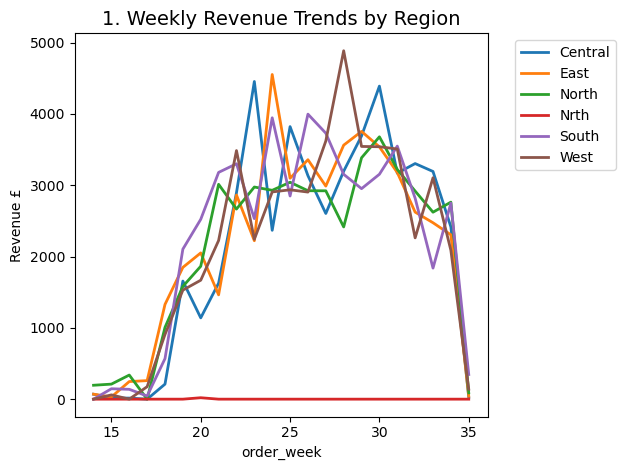

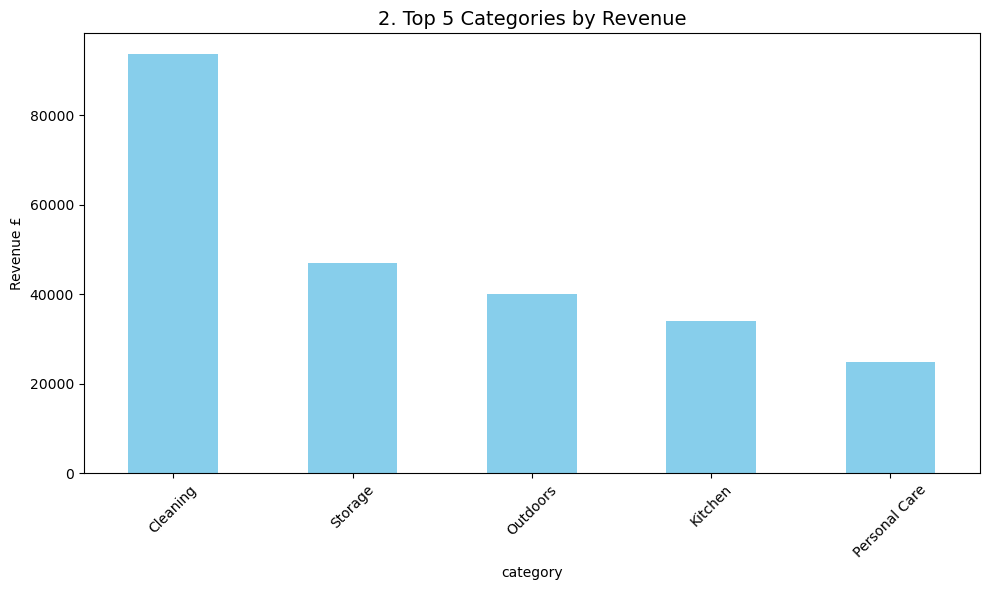

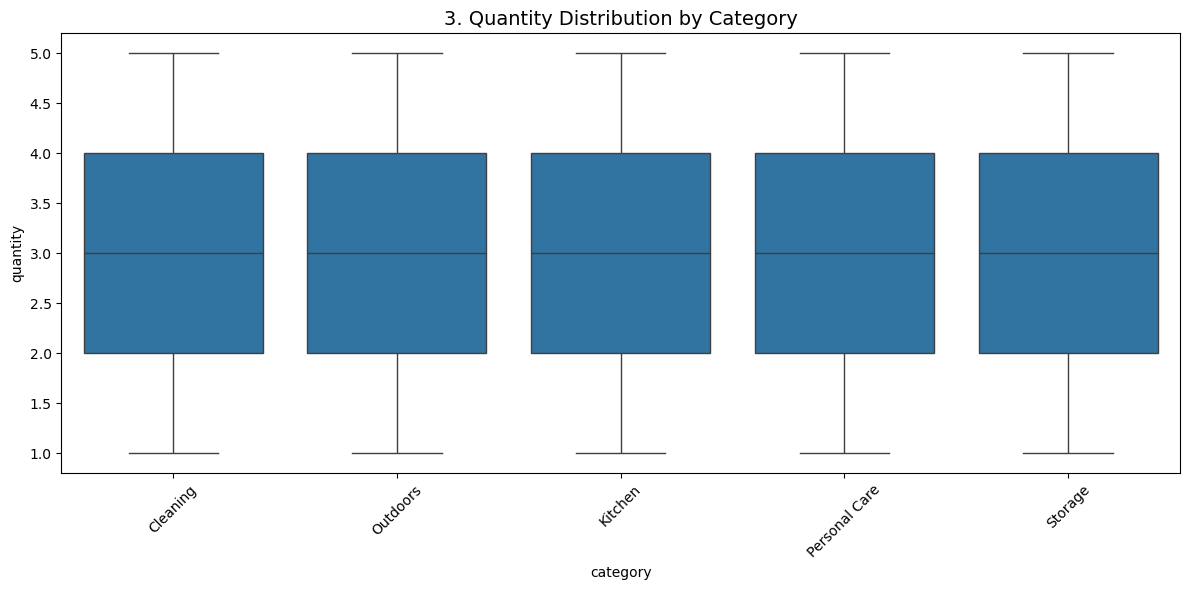

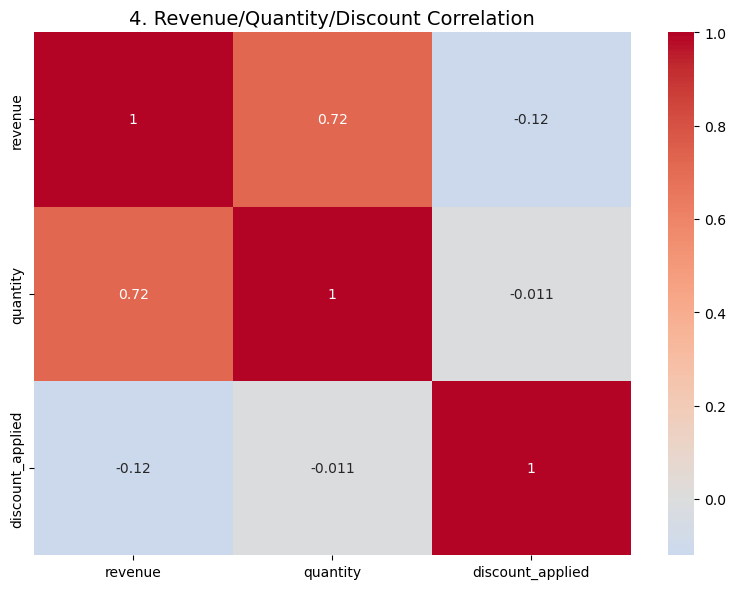

AttributeError: Rectangle.set() got an unexpected keyword argument 'annot'

<Figure size 1200x600 with 0 Axes>

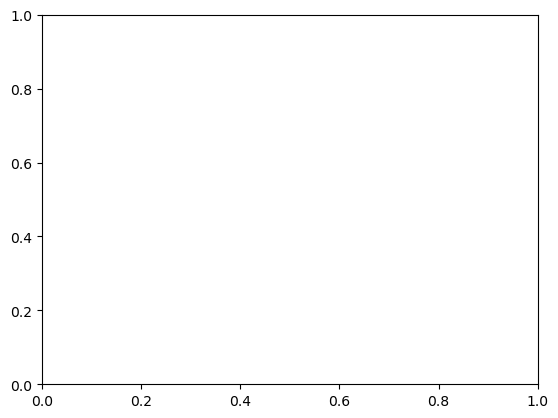

In [24]:

plt.style.use('default')

# 1. Weekly revenue line plot
plt.figure(figsize=(12,6))
weekly_revenue_region.plot(linewidth=2)
plt.title('1. Weekly Revenue Trends by Region', fontsize=14)
plt.ylabel('Revenue £')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('1_weekly_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Top categories bar
plt.figure(figsize=(10,6))
top_cats = cat_perf['revenue'].nlargest(5)
top_cats.plot(kind='bar', color='skyblue')
plt.title('2. Top 5 Categories by Revenue', fontsize=14)
plt.ylabel('Revenue £')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('2_top_categories.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Boxplot quantity by category
plt.figure(figsize=(12,6))
sns.boxplot(data=merged_df, x='category', y='quantity')
plt.title('3. Quantity Distribution by Category', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('3_quantity_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(8,6))
corr_cols = ['revenue', 'quantity', 'discount_applied']
corr = merged_df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('4. Revenue/Quantity/Discount Correlation', fontsize=14)
plt.tight_layout()
plt.savefig('4_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Loyalty orders stacked bar
plt.figure(figsize=(12,6))
loyalty_region = merged_df.groupby(['loyalty_tier', 'region_x'])['order_id'].count().unstack(fill_value=0)
loyalty_region.plot(kind='bar',annot=True, stacked=True)
plt.title('5. Orders by Loyalty Tier & Region', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('5_loyalty_region.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Delivery by price band
plt.figure(figsize=(12,6))
delivery_price = pd.crosstab(merged_df['price_band'], merged_df.get('delivery_status', merged_df['is_late'].map({0:'On Time',1:'Late'})))
delivery_price.plot(kind='bar', stacked=True)
plt.title('6. Delivery Status by Price Band', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('6_delivery_price.png', dpi=300, bbox_inches='tight')
plt.show()

print("All 6 charts saved as PNGs!")
